In [1]:
%load_ext autoreload
%reload_ext autoreload
%autoreload 2

In [6]:
import torch

from utils.model_base_utils import (
    get_device,
    load_model_and_tokenizer
)

from utils.text_utils import (
        generate_text_basic,
        generate_text_basic_stream,
        generate_text_basic_cache,
        generate_text_basic_stream_cache,
        generate_text_stream_concat,
        generate_text_stream_concat_flex,
        generate_text_temp_stream_cache,
        top_p_filter,
        generate_text_top_p_stream_cache
)

from utils.model_eval_utils import (
    get_last_boxed,
    extract_final_candidate,
    normalize_text,
    sympy_parser,
    equality_check,
    split_into_parts,
    grade_answer,
    render_prompt
)

In [7]:
device = get_device()
# device = torch.device("cpu")
 
model, tokenizer = load_model_and_tokenizer(
    which_model="base",
    device=device,
    use_compile=False
)

Using Apple Silicon GPU (MPS)
✓ qwen3/qwen3-0.6B-base.pth already up-to-date


In [8]:
raw_prompt = (
    "Half the value of $3x-9$ is $x+37$. "
    "What is the value of $x$?"
)

prompt = render_prompt(raw_prompt)
print(prompt)

You are a helpful math assistant.
Answer the question and write the final result on a new line as:
\boxed{ANSWER}

Problem:
Half the value of $3x-9$ is $x+37$. What is the value of $x$?

Answer:


In [9]:
response = generate_text_stream_concat_flex(
    model, tokenizer, prompt, device,
    max_new_tokens=2048, verbose=True,
    generate_func=generate_text_basic_stream_cache
)

 \boxed{10}

In [10]:
prompt_cot = prompt + " \n\nExplain step by step."
 
response_cot = generate_text_stream_concat_flex(
    model, tokenizer, prompt_cot, device,
    max_new_tokens=2048, verbose=False,
)

In [27]:
ex_prompt = "The capital of Germany is" 
            # + " \n\nExplain step by step."
 
response = generate_text_stream_concat_flex(
    model, tokenizer, ex_prompt, device,
    max_new_tokens=8, verbose=True
)

 Berlin. Berlin is the capital of Germany

## understanding temp scaling

In [28]:
input_token_ids = torch.tensor(
    tokenizer.encode(ex_prompt), device=device
).unsqueeze(0)
print(input_token_ids)

tensor([[ 785, 6722,  315, 9856,  374]])


In [29]:
with torch.inference_mode():
    next_token_logits = model(input_token_ids)[:, -1]
print(next_token_logits.shape)

torch.Size([1, 151936])


In [30]:
max_token_id = torch.argmax(next_token_logits)
print(f"Token ID: {max_token_id}")
print(f"Decoded token: '{tokenizer.decode([max_token_id])}'")

Token ID: 19846
Decoded token: ' Berlin'


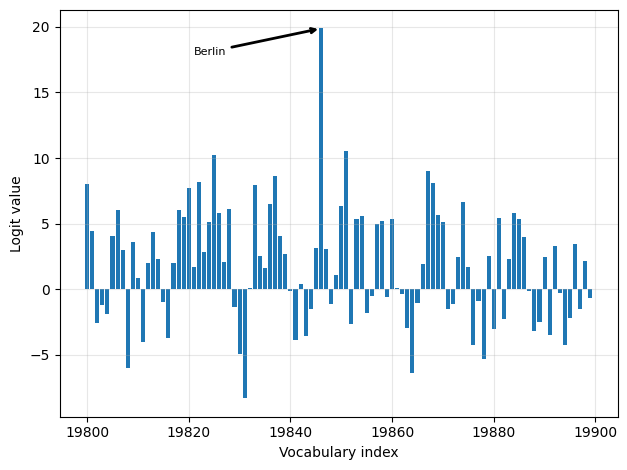

In [31]:
import matplotlib.pyplot as plt
 
def plot_scores_bar(
    next_token_logits, start=19_800, end=19_900,
    arrow=True, ylabel="Logit value"
):
    # Select vocabulary subsection
    x = torch.arange(start, end)
    # .cpu() is a shortcut for to(torch.device("cpu"))
    logits_section = next_token_logits[0, start:end].float().cpu()

    # Plot the logits (scores) within the selected range
    plt.bar(x, logits_section)
    plt.xlabel("Vocabulary index")
    plt.ylabel(ylabel)

    # Draw an arrow to highlight the largest score
    if arrow:
        max_idx = torch.argmax(logits_section)
        plt.annotate(
            "Berlin",
            xy=(x[max_idx], logits_section[max_idx]),
            xytext=(x[max_idx] - 25, logits_section[max_idx] - 2),
            arrowprops={
                "facecolor": "black", "arrowstyle": "->", "lw": 2.0
            },
            fontsize=8,
        )
 
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
 
plot_scores_bar(next_token_logits)

In [32]:
# Temperature < 1.0 => Makes the distribution sharper
def scale_logits_by_temperature(logits, temperature):
    if temperature <= 0:
        raise ValueError("Temperature must be positive")
    return logits / temperature

    
 

In [40]:
def plot_logits_with_temperature(
    next_token_logits, start=19_800, end=19_900,
    temps=(0.5, 5.0),
):
    x = torch.arange(start, end)
    
    # vector of raw scores
    logits_orig = next_token_logits[0, start:end].float().cpu()

    print(f"Original Logits\n: {logits_orig}\n")
    
    # temperature scaling
    logits_scaled = [
        scale_logits_by_temperature(logits_orig, T) for T in temps
    ]

    print(f"Scaled Logits\n: {logits_scaled}\n")

    # Plot logits (scores) within the selected range
    plt.plot(x, logits_orig, label="Original logits", lw=2)
    plt.plot(
        x, logits_scaled[0],
        label=f"T={temps[0]} (sharper)", ls="--", lw=1
    )
    plt.plot(
        x, logits_scaled[1],
        label=f"T={temps[1]} (flatter)", ls=":", lw=3
    )
 
    # Highlight max logit
    max_idx = torch.argmax(logits_orig)
    plt.annotate(
        "Berlin",
        xy=(x[max_idx], logits_orig[max_idx]),
        xytext=(x[max_idx] - 25, logits_orig[max_idx] + 2),
        arrowprops={"facecolor": "black", "arrowstyle": "->", "lw": 1.5},
        fontsize=12,
    )
 
    plt.xlabel("Vocabulary index")
    plt.ylabel("Logit value")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


Original Logits
: tensor([ 8.0000,  4.4062, -2.5625, -1.2109, -1.9219,  4.0312,  6.0625,  2.9688,
        -6.0000,  3.6094,  0.8750, -4.0625,  2.0000,  4.3750,  2.3281, -1.0000,
        -3.7500,  1.9609,  6.0000,  5.5000,  7.7188,  1.6797,  8.1875,  2.8594,
         5.1562, 10.2500,  5.8438,  2.0781,  6.1250, -1.3750, -4.9062, -8.3125,
         0.0962,  7.9375,  2.5625,  1.6484,  6.5312,  8.6250,  4.0312,  2.7188,
        -0.1562, -3.8750,  0.4238, -3.5625, -1.4766,  3.1406, 19.8750,  3.0938,
        -1.1328,  1.0625,  6.3125, 10.5000, -2.6562,  5.3438,  5.5625, -1.8359,
        -0.5039,  5.0000,  5.1875, -0.5703,  5.3438,  0.0640, -0.3477, -2.9688,
        -6.4062, -1.0625,  1.9141,  9.0000,  8.0625,  5.6562,  5.0938, -1.4922,
        -1.1406,  2.4844,  6.6250,  1.6719, -4.2188, -0.8672, -5.3125,  2.5625,
        -3.0469,  5.4375, -2.2812,  2.3281,  5.8438,  5.3750,  4.0000, -0.1621,
        -3.1719, -2.4844,  2.4219, -3.5000,  3.2969, -0.3242, -4.2188, -2.2031,
         3.4219, -1.51

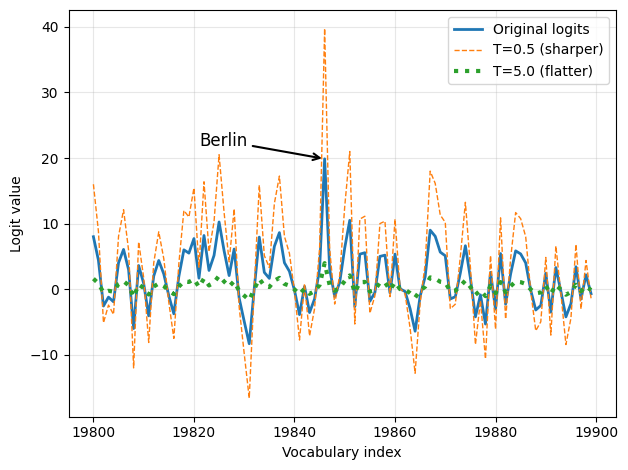

In [41]:
plot_logits_with_temperature(
    next_token_logits,
    temps=(0.5, 5.0)
)

In [104]:
temp = 5.0 # Increased temperature to flatten the distribution
# with temp 0.1, during sampling we can get the desired token
rescaled_logits = scale_logits_by_temperature(
    next_token_logits, 
    temp)
 
next_token_probas = torch.softmax(
    rescaled_logits, dim=-1
)

In [68]:
# TO PROVE SAMPLING FROM RAW SCORES IS NOT DETERMINISTICALLY POSSIBLE
torch.manual_seed(123)
print(
    "Sampled token:",
    torch.multinomial(rescaled_logits.cpu(), num_samples=1)
)

RuntimeError: probability tensor contains either `inf`, `nan` or element < 0

In [96]:
print("Probability sum:", torch.sum(next_token_probas))

Probability sum: tensor(1., dtype=torch.bfloat16)


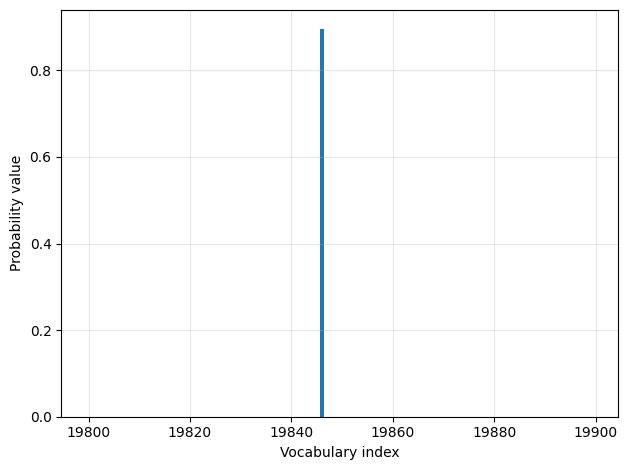

In [97]:
plot_scores_bar(
    next_token_probas,
    start=19_800, 
    end=19_900,
    arrow=False, 
    ylabel="Probability value"
)

In [98]:
print(next_token_probas.argmax(dim=-1, keepdim=True))

tensor([[19846]])


In [99]:
print("Token ID 19,846 probability:", next_token_probas[:, 19846])

Token ID 19,846 probability: tensor([0.8945], dtype=torch.bfloat16)


In [100]:
print("Highest probability:", max(next_token_probas.squeeze(0)))

Highest probability: tensor(0.8945, dtype=torch.bfloat16)


In [101]:
def softmax_with_temperature(logits, temperature):
    scaled_logits = logits / temperature
    return torch.softmax(scaled_logits, dim=0)

In [106]:
torch.manual_seed(123)
sampled_token = torch.multinomial(next_token_probas, 
                                  num_samples=1)
print(
    "Sampled token:",
    sampled_token
)

Sampled token: tensor([[65094]])


In [107]:
print(f"Decoded token: '{tokenizer.decode([sampled_token])}'")

Decoded token: ' mistress'


In [108]:
def count_samples(probas, 
                  num_samples=1000, 
                  threshold=1, 
                  tokenizer=None):
    # Draw samples according to probabilities
    samples = torch.multinomial(
        probas.cpu(), 
        num_samples=num_samples, 
        replacement=True
    )
    # Count how often each index was selected
    counts = torch.bincount(samples.squeeze(0), 
                            minlength=1)
    
    for i, c in enumerate(counts):
        # Print frequently sampled vocabulary indices (entries)
        if c > threshold:
            if tokenizer is None:
                print(f"Vocab index {i}: {c.item()}x")
            else:
                print(f"'{tokenizer.decode([i])}': {c.item()}x")

In [111]:
torch.manual_seed(123)
count_samples(next_token_probas, tokenizer=tokenizer)

'}': 2x
' </': 2x
' represent': 2x
' Inf': 2x
'()*': 2x
' beside': 2x
' Kob': 2x
'�': 2x


In [123]:
torch.manual_seed(123)
temp = 0.35
probas_lowT = torch.softmax(
                    scale_logits_by_temperature(next_token_logits, 
                                                temp), 
                    dim=-1
)
count_samples(probas_lowT, tokenizer=tokenizer)

' __': 158x
' Berlin': 435x
' ____': 169x
' ______': 209x
' Munich': 3x
' Hamburg': 3x
' _____': 18x


In [122]:
print(probas_lowT[0, 19_846])

tensor(0.8945, dtype=torch.bfloat16)


In [126]:
torch.manual_seed(123)
response = generate_text_stream_concat_flex(
    model, tokenizer, prompt, device,
    max_new_tokens=2048, verbose=True,
    generate_func=generate_text_temp_stream_cache,
    temperature=1.1
)

 We begin with the equation \(\frac{1}{2}(3x - 9) = x + 37\).
First, distribute the \(\frac{1}{2}\) on the left-side of the equation to get \(3x - 9 = 2(x + 37)\).
Then simplify the right side of the equation by using the distributive property and combining like terms:

\[3x - 9 = 2x + 74\]

Next, we subtract \(2x\) from both sides of the equation to isolate the \(x\) term:

\(3x - 2x - 9 = 2x - 2x + 74\)
\(x - 9 = 74\)

Then, finally, we add 9 to both sides of the equation to get:

\(x - 9 + 9 = 74 + 9\)
\(x = 83\)
\boxed{83}

#### Recap of temperature scaling and sampling with toy data

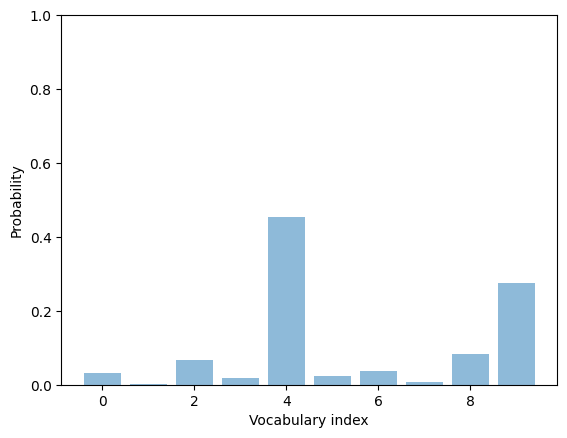

In [127]:
toy_logits = torch.tensor(
    [-0.7, -3.0, 0.1, -1.2, 2.0, -1.0, -0.5, -2.0, 0.3, 1.5]
)
 
toy_logits_scaled = scale_logits_by_temperature(toy_logits, 1.0)
toy_probas = torch.softmax(toy_logits_scaled, dim=-1)
 
plt.bar(
    torch.arange(len(toy_probas)), toy_probas,
    alpha=0.5
)
 
plt.ylim([0, 1])
plt.xlabel("Vocabulary index")
plt.ylabel("Probability")
plt.show()

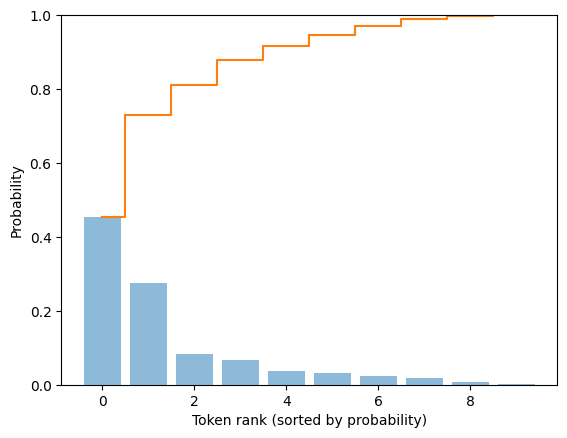

In [128]:
# Sort by descending probability
sorted_probas, sorted_idx = torch.sort(toy_probas, descending=True)
# Compute cumulative sum
cumsum = torch.cumsum(sorted_probas, dim=-1)
 
plt.bar(
    torch.arange(len(sorted_probas)), sorted_probas, 
        alpha=0.5
)
plt.step(
    torch.arange(len(cumsum)), cumsum, 
    where="mid", color="C1", label="Cumulative sum"
)
 
plt.ylim([0, 1])
plt.xlabel("Token rank (sorted by probability)")
plt.ylabel("Probability")
plt.show()

In [129]:
top_p = 0.8
keep_mask = cumsum <= top_p
n_kept = torch.sum(keep_mask).item()
print("Cumulative sum:", cumsum)
print("Tokens kept:", n_kept)
 

Cumulative sum: tensor([0.4538, 0.7290, 0.8119, 0.8798, 0.9170, 0.9475, 0.9701, 0.9886, 0.9969,
        1.0000])
Tokens kept: 2


In [130]:
# the smallest set of tokens is kept such that 
# the cumulative probability mass is at least p
keep_mask = (cumsum - sorted_probas) < top_p
n_kept = keep_mask.sum().item()
print("Tokens kept:", n_kept)
 

Tokens kept: 3


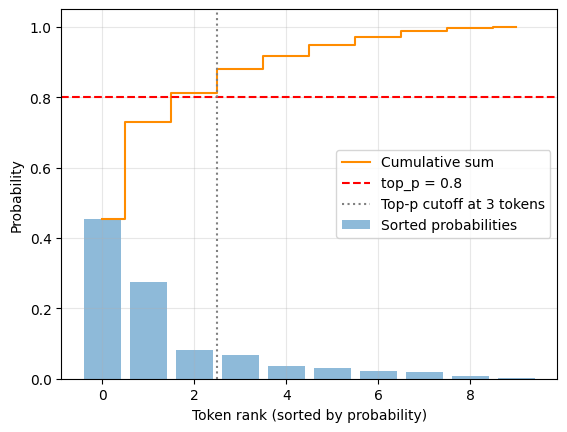

In [131]:
plt.bar(
    torch.arange(len(sorted_probas)), sorted_probas, 
    alpha=0.5, label="Sorted probabilities"
)
plt.step(
    torch.arange(len(cumsum)), cumsum, where="mid",
    color="darkorange", label="Cumulative sum"
)
 
# Highlight cutoff
plt.axhline(
    top_p, color="red", linestyle="--",
    label=f"top_p = {top_p}"
)
plt.axvline(
    n_kept - 0.5, color="gray", linestyle=":",
    label=f"Top-p cutoff at {n_kept} tokens"
)
 
plt.xlabel("Token rank (sorted by probability)")
plt.ylabel("Probability")
plt.legend()
plt.grid(alpha=0.3)
plt.ylim(0, 1.05)
plt.show()
 

In [132]:
kept_sorted = torch.where(
    keep_mask, sorted_probas,
    torch.zeros_like(sorted_probas)
)
filtered = torch.zeros_like(toy_probas).scatter(0, sorted_idx, kept_sorted)
print(filtered)

tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.4538, 0.0000, 0.0000, 0.0000, 0.0829,
        0.2752])


In [133]:
# Clamping prevents that by making the denominator 
# at least a tiny positive number (1e-12), 
# keeping the division numerically safe
denom = torch.sum(filtered).clamp_min(1e-12)
renormalized = filtered / denom
print(renormalized)

tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.5589, 0.0000, 0.0000, 0.0000, 0.1021,
        0.3390])


In [134]:
with torch.inference_mode():
    next_token_logits = model(input_token_ids)[:, -1]
print(next_token_logits.shape)

torch.Size([1, 151936])


In [135]:
torch.manual_seed(123)
probas_lowT = torch.softmax(
    scale_logits_by_temperature(next_token_logits, 0.35), dim=-1
)
count_samples(probas_lowT, threshold=1, tokenizer=tokenizer)

' __': 158x
' Berlin': 435x
' ____': 169x
' ______': 209x
' Munich': 3x
' Hamburg': 3x
' _____': 18x


In [137]:
torch.manual_seed(123)
probas_lowT = torch.softmax(
    scale_logits_by_temperature(next_token_logits, 0.35), dim=-1
)
probas_lowT_filtered = top_p_filter(probas_lowT, top_p=0.8)
count_samples(probas_lowT_filtered, threshold=1, tokenizer=tokenizer)

' Berlin': 534x
' ____': 217x
' ______': 249x


In [139]:
torch.manual_seed(123)
response = generate_text_stream_concat_flex(
    model, tokenizer, prompt, device,
    max_new_tokens=2048, verbose=True,
    generate_func=generate_text_top_p_stream_cache,
    temperature=0.5,
    top_p=0.8, 
)

 \boxed{18}

In [140]:
prompt

'You are a helpful math assistant.\nAnswer the question and write the final result on a new line as:\n\\boxed{ANSWER}\n\nProblem:\nHalf the value of $3x-9$ is $x+37$. What is the value of $x$?\n\nAnswer:'

In [141]:
from collections import Counter
 
def self_consistency_vote(
    model, 
    tokenizer, 
    prompt, 
    device,
    num_samples=10, 
    temperature=0.8, 
    top_p=0.9, 
    max_new_tokens=2048,
    show_progress=True, 
    show_long_answer=False, 
    seed=None,
):
    full_answers, short_answers = [], []
 
    for i in range(num_samples):
        if seed is not None:
            torch.manual_seed(seed + i + 1)
 
        answer = generate_text_stream_concat_flex(
            model=model, tokenizer=tokenizer, prompt=prompt, 
            device=device,
            max_new_tokens=max_new_tokens, 
            verbose=show_long_answer,
            generate_func=generate_text_top_p_stream_cache,
            temperature=temperature, 
            top_p=top_p,
        )
 
        short = extract_final_candidate(
            answer, fallback="number_then_full"
        )
        full_answers.append(answer)
        short_answers.append(short)
        if show_progress:
            print(f"[Sample {i+1}/{num_samples}] → {short!r}")
 
    counts = Counter(short_answers)
    groups = {s: [] for s in counts}
    for idx, s in enumerate(short_answers):
        groups[s].append(idx)
 
    mc = counts.most_common()
    if not mc:
        majority_winners, final_answer = [], None
    else:
        top_freq = mc[0][1]
        majority_winners = [s for s, f in mc if f == top_freq]
        final_answer = mc[0][0] if len(majority_winners) == 1 else None
 
    return {
        "full_answers": full_answers,
        "short_answers": short_answers,
        "counts": dict(counts),
        "groups": groups,
        "majority_winners": majority_winners,
        "final_answer": final_answer,
    }

In [146]:
results = self_consistency_vote(
    model,
    tokenizer,
    prompt,
    device=device,
    num_samples=5,
    temperature=0.8,
    top_p=0.9,
    max_new_tokens=2048,
    seed=42,
    show_progress=True,
)

[Sample 1/5] → '10'
[Sample 2/5] → '83'
[Sample 3/5] → '83'
[Sample 4/5] → '46'
[Sample 5/5] → '37'


In [150]:
print(results["groups"])

{'10': [0], '83': [1, 2], '46': [3], '37': [4]}


In [151]:
results = self_consistency_vote(
    model,
    tokenizer,
    prompt + "\n\nExplain step by step.",
    device=device,
    num_samples=5,
    temperature=0.8,
 
    top_p=0.9,
    max_new_tokens=2048,
    seed=42,
    show_progress=True,
)

[Sample 1/5] → '83'
[Sample 2/5] → '83'
[Sample 3/5] → '83'
[Sample 4/5] → '83'
[Sample 5/5] → '83'


### Simple Example

In [109]:
from collections import Counter

# An iterable (list) with repeated elements
data = ['apple', 'banana', 'apple', 'orange', 'banana', 'apple', 'grape', 'grape']

# Create a Counter object
counter = Counter(data)

# Find the 2 most common elements
most_common_elements = counter.most_common()

print(f"Original data: {data}")
print(f"Counter object: {counter}")
print(f"Most common 2 elements: {most_common_elements}")


Original data: ['apple', 'banana', 'apple', 'orange', 'banana', 'apple', 'grape', 'grape']
Counter object: Counter({'apple': 3, 'banana': 2, 'grape': 2, 'orange': 1})
Most common 2 elements: [('apple', 3), ('banana', 2), ('grape', 2), ('orange', 1)]


In [ ]:
top_freq = most_common_elements[0][1]

In [ ]:
top_freq